# NLP课程第2周第1课：构建模型 - 课堂练习01
预计耗时：10分钟
<br>
# 词汇表构建
基于小型语料库创建简易词汇表
<br>
从小规模实验开始！
<br>
### 导入模块与准备数据

In [1]:
# 导入模块
import re  # 正则表达式库，用于单词分词
from collections import Counter  # collections工具库；Counter是字典子类，用于统计可哈希对象的数量
import matplotlib.pyplot as plt  # 用于数据可视化

In [2]:
# 小型文本语料！
text = 'red pink pink blue blue yellow ORANGE BLUE BLUE PINK' # 🌈
print(text)
print('字符串长度：',len(text))

red pink pink blue blue yellow ORANGE BLUE BLUE PINK
字符串长度： 52


### Preprocessing

In [4]:
# 将所有字母转为小写
text_lowercase = text.lower()
print(text_lowercase)
print('字符串长度：', len(text_lowercase))

red pink pink blue blue yellow orange blue blue pink
字符串长度： 52


In [5]:
# 使用正则表达式将字符串切分为单词，并以列表形式返回
words = re.findall(r'\w+', text_lowercase)
print(words)
print('单词数量：', len(words))

['red', 'pink', 'pink', 'blue', 'blue', 'yellow', 'orange', 'blue', 'blue', 'pink']
单词数量： 10


### 创建词汇表
方案1：提取文本中不重复单词构成集合

In [6]:
# create vocab
vocab = set(words)
print(vocab)
print('count : ',len(vocab))

{'yellow', 'blue', 'orange', 'pink', 'red'}
count :  5


### 附带单词计数信息
方案2：两种实现方式，同时保存单词与对应词频

In [7]:
# 创建带有单词计数的词汇表
counts_a = dict()
for w in words:
    counts_a[w] = counts_a.get(w,0)+1
print(counts_a)
print('不重复单词总数：',len(counts_a))

{'red': 1, 'pink': 3, 'blue': 4, 'yellow': 1, 'orange': 1}
不重复单词总数： 5


In [8]:
# create vocab including word count using collections.Counter
counts_b = dict()
counts_b = Counter(words)
print(counts_b)
print('count : ',len(counts_b))

Counter({'blue': 4, 'pink': 3, 'red': 1, 'yellow': 1, 'orange': 1})
count :  5


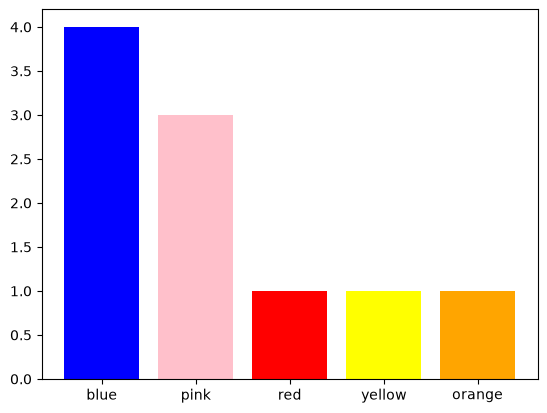

In [9]:
# 绘制按词频排序的柱状图
d = {'blue': counts_b['blue'], 'pink': counts_b['pink'], 'red': counts_b['red'], 'yellow': counts_b['yellow'], 'orange': counts_b['orange']}
plt.bar(range(len(d)), list(d.values()), align='center', color=d.keys())
_ = plt.xticks(range(len(d)), list(d.keys()))

### 非计分练习题
注意：上方由 `collections.Counter` 得到的 `counts_b`，会按照单词出现频次排序。

你能否修改小型语料变量 ***text***，使得 `counts_b` 中新增加一种颜色，并且该颜色条目出现在 ***pink*** 与 ***red*** 之间？

你需要重新运行全部代码单元格，还是只需要运行特定单元格？

In [10]:
print('counts_b : ', counts_b)
print('count : ', len(counts_b))

counts_b :  Counter({'blue': 4, 'pink': 3, 'red': 1, 'yellow': 1, 'orange': 1})
count :  5


Expected Outcome:

counts_b : Counter({'blue': 4, 'pink': 3, **'your_new_color_here': 2**, red': 1, 'yellow': 1, 'orange': 1})
<br>
count :  6

### Summary

This is a tiny example but the methodology scales very well.
<br>
In the assignment you will create a large vocabulary of thousands of words, from a corpus
<br>
of tens of thousands or words! But the mechanics are exactly the same. 
<br> 
The only extra things to pay attention to should be; run time, memory management and the vocab data structure.
<br> 
So the choice of approach used in code blocks `counts_a` vs `counts_b`, above, will be important.